In [21]:
import mlflow
# setup to mlflow tracking server
mlflow.set_tracking_uri('http://13.51.166.199:5000')

In [22]:
# Set or create an experiment
mlflow.set_experiment("Exp 5 - LightGBM HP Tuning")

<Experiment: artifact_location='s3://mlfow-test60/8', creation_time=1776830504313, experiment_id='8', last_update_time=1776830504313, lifecycle_stage='active', name='Exp 5 - LightGBM HP Tuning', tags={}>

In [32]:
import optuna
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv('preprocessed_data.csv').dropna()
df.shape

(36662, 5)

# Helper Function

In [33]:
# Define a function to vectorize the data using TF-IDF
def vectorize_data(X_train, X_val, X_test, max_features, ngram_range):
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train_vec = vectorizer.fit_transform(X_train['comment']).toarray()
    X_val_vec = vectorizer.transform(X_val['comment']).toarray()
    X_test_vec = vectorizer.transform(X_test['comment']).toarray()

    # Combine additional features
    X_train_combined = np.hstack([X_train_vec, X_train[['word_count', 'char_count', 'avg_word_length']].values])
    X_val_combined = np.hstack([X_val_vec, X_val[['word_count', 'char_count', 'avg_word_length']].values])
    X_test_combined = np.hstack([X_test_vec, X_test[['word_count', 'char_count', 'avg_word_length']].values])

    return X_train_combined, X_val_combined, X_test_combined


# Define the function that evaluates the model on validation data
def evaluate_model(model, X_val, y_val):
    y_val_pred = model.predict(X_val)  # Predict on validation set
    f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)  # Calculate F1 (macro)
    accuracy = accuracy_score(y_val, y_val_pred)  # Calculate accuracy
    return f1, accuracy, y_val_pred

# Read and Vectorized Data

In [26]:


# Remap the class labels from [-1, 0, 1] to [0, 1, 2]
df['category'] = df['category'].map({-1: 0, 0: 1, 1: 2})

df.shape

(36662, 5)

In [34]:
max_features = 9410
ngram_range = (1, 2)

# Split data into training, validation and testing sets
X = df[['comment', 'word_count', 'char_count', 'avg_word_length']]
y = df['category']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.4, random_state=42, stratify=y_temp)

In [35]:
# Vectorize the data
X_train_combined, X_val_combined, X_test_combined = vectorize_data(X_train, X_val, X_test, max_features, ngram_range)

In [36]:
import os
os.cpu_count()

16

# HP Tuning using Optuna

In [37]:
# Define the Optuna objective function for LightGBM
def objective_lgbm(trial):

    n_estimators = trial.suggest_int("n_estimators", 150, 1000, step=10)
    max_depth = trial.suggest_int("max_depth", 3, 25)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    num_leaves = trial.suggest_int("num_leaves", 20, 150)
    min_child_samples = trial.suggest_int("min_child_samples", 5, 100)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)

    # Initialize LightGBM model with GPU support
    model = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        objective='multiclass',
        num_class=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=16,
        force_col_wise=True,
        verbosity=-1
        
    )

    # Log each trial to MLflow
    trial_name = f"trial-{trial.number + 1}"
    with mlflow.start_run(run_name=trial_name):
        # Fit the model on the training data
        model.fit(X_train_combined, y_train)

        # Evaluate model on the validation set
        f1, accuracy, y_val_pred = evaluate_model(model, X_val_combined, y_val)

        # Log hyperparameters and metrics to MLflow
        mlflow.log_params({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "learning_rate": learning_rate,
            "num_leaves": num_leaves,
            "min_child_samples": min_child_samples,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "reg_alpha": reg_alpha,
            "reg_lambda": reg_lambda,
            "objective": 'multiclass',
            "num_class": 3,
            "class_weight": 'balanced',
            "random_state": 42
        })

        mlflow.log_metric("accuracy", accuracy)

        # Logging the classification report
        #classification_rep = classification_report(y_val, y_val_pred, output_dict=True)
        #for label, metrics in classification_rep.items():
            #if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
                #for metric, value in metrics.items():
                    #mlflow.log_metric(f"{label}_{metric}", value)

        # Confusion matrix plot
        #conf_matrix = confusion_matrix(y_val, y_val_pred)
        #plt.figure(figsize=(8, 6))
        #sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
        #plt.xlabel("Predicted")
        #plt.ylabel("Actual")
        #plt.title("Confusion Matrix")

        # Save and log the confusion matrix plot
        #plt.savefig("confusion_matrix.png")
        #mlflow.log_artifact("confusion_matrix.png")
        #plt.close()

    return accuracy, f1

In [15]:
# Run Optuna optimization
study_lgbm = optuna.create_study(directions=["maximize", "maximize"], study_name="LightGBM_Optimization")  # Multi-objective optimization for both F1 and accuracy
study_lgbm.optimize(objective_lgbm, n_trials=100,n_jobs=1)

[I 2026-04-22 10:12:20,140] A new study created in memory with name: LightGBM_Optimization
2026/04/22 10:14:02 INFO mlflow.tracking._tracking_service.client: 🏃 View run trial-1 at: http://13.51.166.199:5000/#/experiments/8/runs/d5841b94eed9430d8d50d6adc18836a7.
2026/04/22 10:14:02 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://13.51.166.199:5000/#/experiments/8.
[I 2026-04-22 10:14:03,564] Trial 0 finished with values: [0.6981269321694854, 0.6814841469611045] and parameters: {'n_estimators': 890, 'max_depth': 12, 'learning_rate': 0.002677571553515337, 'num_leaves': 39, 'min_child_samples': 69, 'subsample': 0.6985115016990566, 'colsample_bytree': 0.9206574505282501, 'reg_alpha': 0.0014834551585067393, 'reg_lambda': 0.057633059285891186}.
2026/04/22 10:15:17 INFO mlflow.tracking._tracking_service.client: 🏃 View run trial-2 at: http://13.51.166.199:5000/#/experiments/8/runs/04f7bb2a01e24f1ab961d9c905f5e2c8.
2026/04/22 10:15:17 INFO mlflow.tracking._tracking_se

In [38]:
best_trial = sorted(study_lgbm.best_trials, key=lambda t: t.values[0], reverse=True)[0]
best_trial

FrozenTrial(number=78, state=<TrialState.COMPLETE: 1>, values=[0.8708856155664666, 0.856757572941843], datetime_start=datetime.datetime(2026, 4, 22, 11, 58, 5, 86031), datetime_complete=datetime.datetime(2026, 4, 22, 11, 59, 18, 625304), params={'n_estimators': 710, 'max_depth': 10, 'learning_rate': 0.08954927952621261, 'num_leaves': 69, 'min_child_samples': 9, 'subsample': 0.5660834374933594, 'colsample_bytree': 0.6587059867598111, 'reg_alpha': 2.8937312709320326e-05, 'reg_lambda': 6.896971770626064e-05}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 1}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=150, step=10), 'max_depth': IntDistribution(high=25, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.0001, step=None), 'num_leaves': IntDistribution(high=150, log=False, low=20, step=1), 'min_child_samples': IntDistribution(high=100, log=False, low=5, step=1), 'subsample': FloatDistributio

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_cleaned = TfidfVectorizer(
    max_features=9410,
    ngram_range=(1,2)
)

tfidf_cleaned.fit(X_train['comment'])

TfidfVectorizer(max_features=9410, ngram_range=(1, 2))

Text(0.5, 1.0, 'Confusion Matrix - LightGBM')

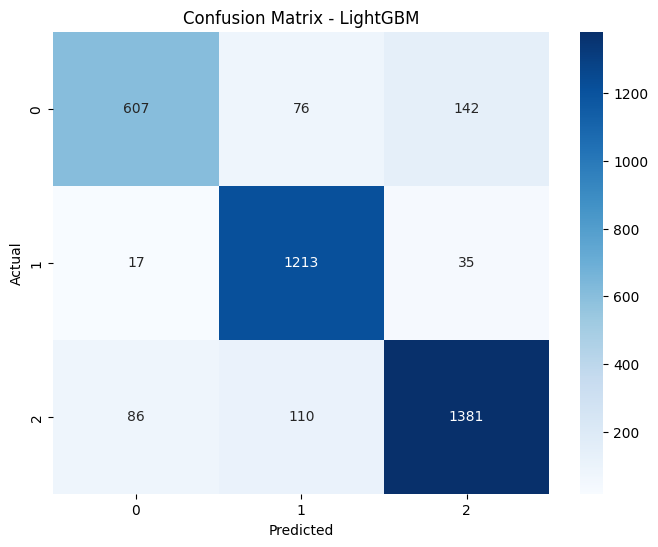

In [39]:
# Extract parameters from the best trial
best_params = best_trial.params

# Initialize the model using the best trial parameters with unpacking (**)
model = lgb.LGBMClassifier(
                          objective='multiclass',   # Multi-class classification objective
                          num_class=3,              # Number of classes
                          random_state=42, **best_trial.params)

# Train the model on the resampled training data
model.fit(X_train_combined, y_train)

# Predictions on the test set
y_test_pred = model.predict(X_test_combined)

# Log classification metrics
classification_rep = classification_report(y_test, y_test_pred, output_dict=True)
accuracy = accuracy_score(y_test, y_test_pred)

# Generate and log confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - LightGBM")

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79       825
           1       0.87      0.96      0.91      1265
           2       0.89      0.88      0.88      1577

    accuracy                           0.87      3667
   macro avg       0.87      0.86      0.86      3667
weighted avg       0.87      0.87      0.87      3667



In [41]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_test, y_test_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0,0.854930,0.735758,0.790879,825.000000
1,0.867048,0.958893,0.910661,1265.000000
2,0.886393,0.875713,0.881021,1577.000000
accuracy,0.872921,0.872921,0.872921,0.872921
macro avg,0.869457,0.856788,0.860854,3667.000000
weighted avg,0.872641,0.872921,0.870966,3667.000000


In [49]:
import re
import numpy as np

# Assuming you have pre-trained tfidf_vectorizer and lgbm_model loaded
# tfidf_vectorizer: Your trained TF-IDF vectorizer
# lgbm_model: Your trained LightGBM model

# Function to clean and preprocess a YouTube comment (same as used during training)
def preprocess_comment(comment):
    # Lowercasing
    comment = comment.lower()

    # Remove special characters, URLs, punctuation, and extra spaces
    comment = re.sub(r"http\S+|www\S+|https\S+", '', comment, flags=re.MULTILINE)  # Remove URLs
    comment = re.sub(r'\W', ' ', comment)  # Remove special characters
    comment = re.sub(r'\s+', ' ', comment).strip()  # Remove extra spaces and newlines

    return comment

# Prediction function
def predict_sentiment(comment, tfidf_vectorizer, lgbm_model):
    
    cleaned_comment = preprocess_comment(comment)

    # TF-IDF
    comment_tfidf = tfidf_vectorizer.transform([cleaned_comment]).toarray()

    # Extra numerical features
    word_count = len(cleaned_comment.split())
    char_count = len(cleaned_comment)
    avg_word_length = np.mean([len(word) for word in cleaned_comment.split()]) if word_count > 0 else 0

    extra_features = np.array([[word_count, char_count, avg_word_length]])

    # Combine = 9413 features
    final_input = np.hstack([comment_tfidf, extra_features])

    # Predict
    prediction = lgbm_model.predict(final_input)
    prediction_proba = lgbm_model.predict_proba(final_input)

    return {
        "sentiment_class": int(prediction[0]),
        "confidence": float(np.max(prediction_proba))
    }

# Example usage:
comment1 = "I absolutely love this video!"
comment2 = "The explanations were confusing and the video quality was poor."
comment3 = "I didn’t learn anything useful. Really disappointed."
comment4 = "Wow, the explanation was so clear and helpful. Definitely subscribing!"
comment5 = "This is the worst video I’ve seen on this topic, very misleading"
comment6 = "Not much to say about this, just a standard video."
comment7 = "The video is okay, but I expected more depth in the content."
comment8 = "Superb content! Mazaa aa gaya dekh ke. Best video on this topic!"
comment9 = "Poor video quality aur explanation bhi weak tha."
comment10 = "Yeh video theek tha, but I was expecting more depth."
result = predict_sentiment(comment1, tfidf_cleaned, model)
print(f"Predicted Sentiment: {result['sentiment_class']}, Confidence: {result['confidence']}")

Predicted Sentiment: 2, Confidence: 0.9902297534488823
